In [23]:
import os
import glob
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


# ----------------------------------------------------------
# Function: Collect all eval_results.txt under root/*_vs_*_k4/
# ----------------------------------------------------------
def collect_metrics(root: str):
    """
    Scan root/*_vs_*_k4 directories and extract mean ACC/AUC/F1
    from eval_results.txt files.

    Returns:
        metrics: dict { (cellA, cellB): {"acc": x, "auc": y, "f1": z} }
    """
    pat = re.compile(r"(.+?)_vs_(.+?)_k4$")
    metrics = {}

    for txt in glob.glob(os.path.join(root, "*_vs_*_k4", "eval_results.txt")):
        parent = os.path.basename(os.path.dirname(txt))
        m = pat.match(parent)
        if not m:
            continue

        c1, c2 = m.group(1), m.group(2)
        key = tuple(sorted((c1, c2)))  # sorted so A_vs_B = B_vs_A

        df = pd.read_csv(
            txt,
            sep=r"\s+",
            header=None,
            names=["label", "acc", "auc", "f1"]
        )

        metrics[key] = {
            "acc": df["acc"].mean(),
            "auc": df["auc"].mean(),
            "f1": df["f1"].mean(),
        }

    return metrics


# ----------------------------------------------------------
# Build matrices for each metric
# ----------------------------------------------------------
def build_matrices(metrics: dict):
    """
    Convert the metrics dict into 3 symmetric matrices (AUC, ACC, F1).
    """
    cells = sorted({c for pair in metrics for c in pair})
    n = len(cells)

    idx = {c: i for i, c in enumerate(cells)}
    mats = {k: np.full((n, n), np.nan) for k in ["auc", "acc", "f1"]}

    for (c1, c2), vals in metrics.items():
        i, j = idx[c1], idx[c2]
        for k in mats:
            mats[k][i, j] = mats[k][j, i] = vals[k]

    return cells, mats


# ----------------------------------------------------------
# Plotting helper
# ----------------------------------------------------------
def plot_heatmap(mat, cells, title, ax, vmin=0.2, vmax=1.0, cmap_name="Oranges"):
    """
    Plot lower-triangle annotated heatmap.
    Automatically uses white text on dark cells and black text on light cells.
    """

    # Load colormap
    cmap = plt.cm.get_cmap(cmap_name)

    # Normalize matrix for luminance evaluation
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # Draw heatmap
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)

    # REMOVE OUTER BORDER 
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(range(len(cells)))
    ax.set_yticks(range(len(cells)))
    ax.set_xticklabels(cells, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(cells, fontsize=11)
    ax.set_title(title)

    # Annotate lower triangle
    for i in range(len(cells)):
        for j in range(i + 1):
            val = mat[i, j]
            if not np.isnan(val):

                # Get background RGBA color
                rgba = cmap(norm(val))
                r, g, b, _ = rgba

                # Perceptual luminance
                luminance = 0.299*r + 0.587*g + 0.114*b

                text_color = "white" if luminance < 0.5 else "black"

                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=11,
                    color=text_color
                )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)



# ----------------------------------------------------------
# Save AUC/ACC/F1 heatmaps into one PDF
# ----------------------------------------------------------
def save_pdf(cells, mats, outfile):
    with PdfPages(outfile) as pdf:
        for key, title in [
            ("auc", "Mean AUC"),
            ("acc", "Mean Accuracy"),
            ("f1", "Mean F1 Score"),
        ]:
            fig, ax = plt.subplots(figsize=(8, 6))
            plot_heatmap(mats[key], cells, title, ax)
            fig.tight_layout()
            pdf.savefig(fig)
            plt.show() 


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_59521/1352465507.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


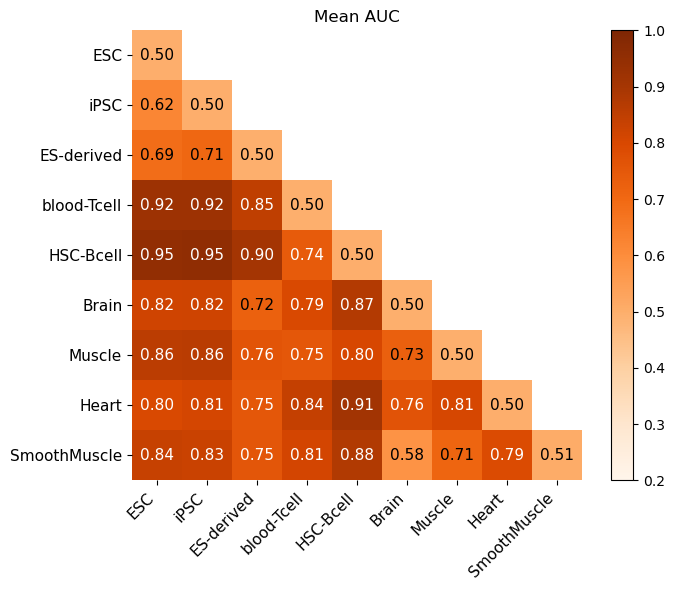

Saved: Revision_code/Supp/heatmap_auc.pdf


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_59521/1352465507.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


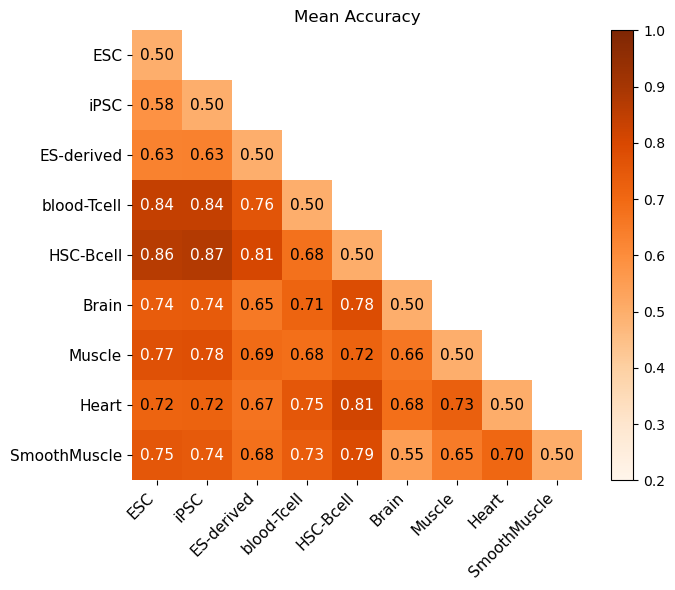

Saved: Revision_code/Supp/heatmap_accuracy.pdf


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_59521/1352465507.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


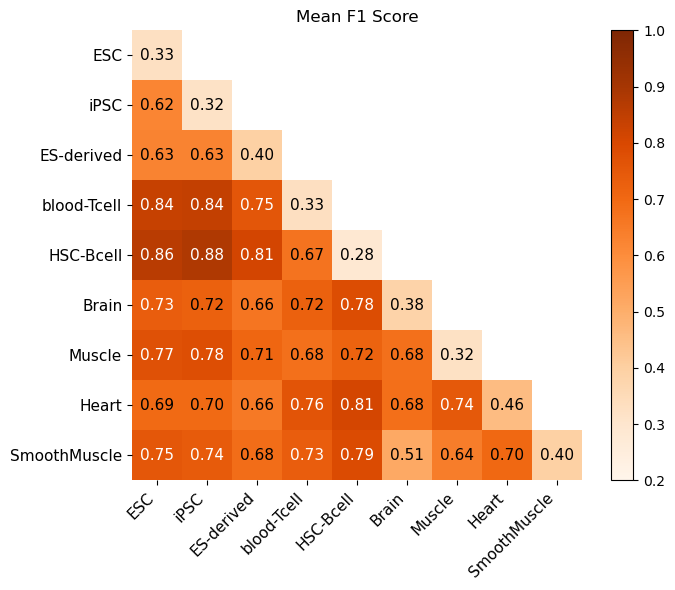

Saved: Revision_code/Supp/heatmap_f1.pdf


In [24]:
from matplotlib import pyplot as plt

# -------------------- SETTINGS --------------------
# Root directory containing *_vs_*_k4 subfolders (LOCAL path)
root_dir = "../revision_temp/finetune_results_train30000_dev5000_notomitO_finetunedebug/up20000_down5000_stride1_notomitO"

# Output directory for the 3 figure PDFs
outdir = Path("./Revision_code/Supp")
outdir.mkdir(parents=True, exist_ok=True)

# Desired order of cell types (subset of what you actually have)
desired_order = [
    "ESC", "iPSC", "ES-derived", "blood-Tcell", "HSC-Bcell",
    "Brain", "Muscle", "Heart", "SmoothMuscle"
]
# ---------------------------------------------------


# 1. Collect metrics from eval_results.txt files
metrics = collect_metrics(str(root_dir))
if not metrics:
    raise RuntimeError(f"No eval_results.txt found under: {root_dir}")

# 2. Build metric matrices
cells, mats = build_matrices(metrics)

# 3. Reorder cells according to desired_order
cells_reordered = [c for c in desired_order if c in cells]
idx = {c: i for i, c in enumerate(cells)}
perm = [idx[c] for c in cells_reordered]

for k in mats:
    mats[k] = mats[k][np.ix_(perm, perm)]

cells = cells_reordered

# 4. Mask upper triangle (keep only lower triangle + diagonal)
n = len(cells)
tril_mask = np.tril(np.ones((n, n), dtype=bool), k=0)
for k in mats:
    mats[k][~tril_mask] = np.nan


# 5. Plot and save three separate PDFs (AUC, Accuracy, F1)
metric_map = [
    ("auc", "Mean AUC", outdir / "heatmap_auc.pdf"),
    ("acc", "Mean Accuracy", outdir / "heatmap_accuracy.pdf"),
    ("f1",  "Mean F1 Score", outdir / "heatmap_f1.pdf"),
]

for key, nice_title, outpath in metric_map:
    fig, ax = plt.subplots(figsize=(8, 6))

    plot_heatmap(
        mats[key],
        cells,
        nice_title,
        ax,
        vmin=0.2,
        vmax=1.0,
        cmap_name="Oranges",
    )

    fig.tight_layout()
    fig.savefig(outpath, dpi=300)
    plt.show()
    plt.close(fig)

    print(f"Saved: {outpath}")
